In [22]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader


In [23]:
from util.data_path import cassava_path

In [24]:
wide = pd.read_csv(cassava_path)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

In [25]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

In [26]:
SEQ_LEN = 12
PRED_LEN = 12

In [27]:
from util.transformer_cust_class import SeqDataset, TransformerRegressor


In [28]:
series_scaled = train["scaled"].values.astype(np.float32)

ds = SeqDataset(series_scaled, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

In [29]:
model_tf = TransformerRegressor()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_tf.parameters(), lr=1e-3)

In [30]:
EPOCHS = 400
for epoch in range(1, EPOCHS + 1):
    for xb, yb in loader:
        optimizer.zero_grad()
        y_pred = model_tf(xb)  # (B, 12)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} — loss = {loss.item():.6f}")


Epoch  50/400 — loss = 0.036362
Epoch 100/400 — loss = 0.024180
Epoch 150/400 — loss = 0.021628
Epoch 200/400 — loss = 0.017000
Epoch 250/400 — loss = 0.014588
Epoch 300/400 — loss = 0.012314
Epoch 350/400 — loss = 0.010249
Epoch 400/400 — loss = 0.010638


In [31]:
# 5. Roll-forward prediction for 2567 ------------------------------------------
model_tf.eval()
with torch.no_grad():
    window = (
        torch.tensor(series_scaled[-SEQ_LEN:], dtype=torch.float32)
        .unsqueeze(0)
        .unsqueeze(-1)
    )
    tf_forecast_scaled = model_tf(window).squeeze(0).numpy()
    tf_forecast = scaler.inverse_transform(tf_forecast_scaled.reshape(-1, 1)).flatten()

tf_forecast = pd.Series(
    tf_forecast,
    index=pd.date_range("2024-01-01", periods=12, freq="MS"),
    name="TF_forecast",
)

mae_tf = mean_absolute_error(future["price"], tf_forecast)
print(f"\nTransformer MAE 2567 = {mae_tf:.4f}")

display(pd.concat([future["price"].rename("actual"), tf_forecast], axis=1))



Transformer MAE 2567 = 0.3806


,actual,TF_forecast
2024-01-01,3.65,3.332031
2024-02-01,3.65,3.216602
2024-03-01,3.57,3.051154
2024-04-01,3.24,3.024073
2024-05-01,3.19,3.172603
2024-06-01,3.09,3.078152
2024-07-01,3.06,3.076461
2024-08-01,2.95,3.278640
2024-09-01,2.86,3.130786
2024-10-01,2.65,3.261460


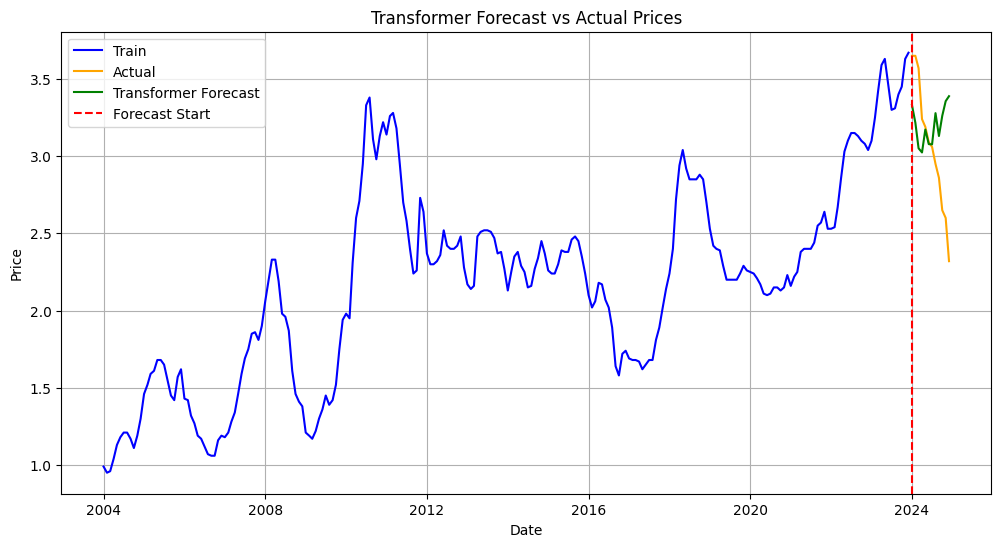

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(train.index, train["price"], label="Train", color="blue")
plt.plot(future.index, future["price"], label="Actual", color="orange")
plt.plot(tf_forecast.index, tf_forecast, label="Transformer Forecast", color="green")
plt.axvline(
    x=pd.Timestamp("2024-01-01"), color="red", linestyle="--", label="Forecast Start"
)
plt.title("Transformer Forecast vs Actual Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()